<div class="cover">
<h1>Lab 5</h1>
<h2>Spatial Filtering – Smoothing and Sharpening</h2>
<h3>Image Processing</h3>
<p><b>Name:</b> Abdullah Alnuwaysir</p>
<p><b>ID:</b> 2240005501</p>
<p>College of Computer Science and Information Technology<br>Imam Abdulrahman Bin Faisal University</p>
<p>2025 - 2026</p>
</div>
<div style="page-break-after: always;"></div>

## Practical Task – Unsharp Masking

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Create the images folder with sample images if they are missing
os.makedirs('images', exist_ok=True)
from skimage import data
for name in ['coffee', 'chelsea', 'astronaut']:
    p = f'images/{name}.png'
    if not os.path.exists(p):
        cv2.imwrite(p, cv2.cvtColor(getattr(data, name)(), cv2.COLOR_RGB2BGR))

def load_rgb(path):
    img = cv2.imread(path)
    assert img is not None, f"Could not read {path}"
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR -> RGB

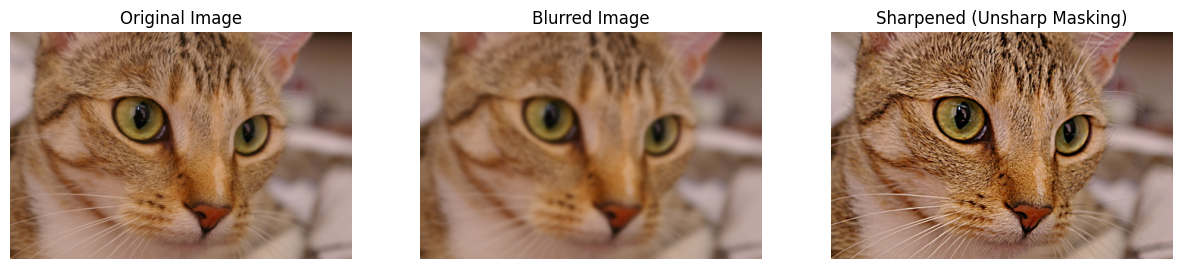

In [2]:
# Read the image (uses Parrot.png if it exists, otherwise a sample image)
path = 'images/Parrot.png' if os.path.exists('images/Parrot.png') else 'images/chelsea.png'
image = load_rgb(path)

# Gaussian sigma
sigma = 2

# parameter
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")

ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")

plt.show()

### Unsharp Masking step by step (Mask and High-Boost)

1. **Smoothing (low-pass):** Blurred = Gaussian(f)
2. **Mask (high-frequency):** Mask = f - Blurred
3. **Sharpening:** Sharpened = f + k * Mask  (k = 1: standard unsharp masking, k > 1: high-boost filtering)

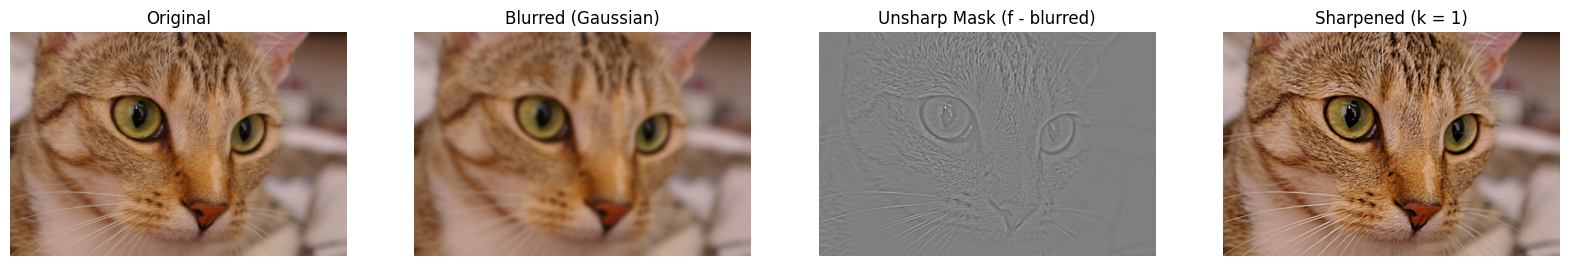

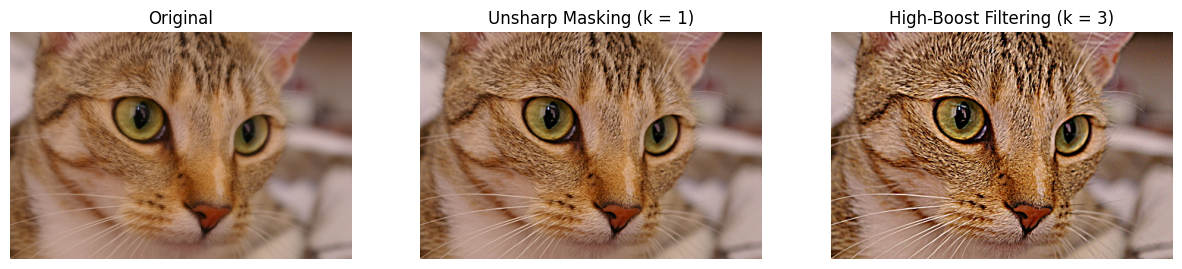

In [3]:
# Step 1: smoothing (low-pass filter)
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Step 2: unsharp mask (high-frequency details / edges)
mask = image_float - blurred

# Step 3: sharpening  ->  f + k * mask
def sharpen(f, m, k):
    return np.clip(f + k * m, 0, 1)

standard   = sharpen(image_float, mask, k=1)    # standard unsharp masking
high_boost = sharpen(image_float, mask, k=3)    # high-boost filtering

# Step 4: visualization (original, blurred, mask, sharpened)
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image);                         ax[0].set_title("Original")
ax[1].imshow(blurred);                       ax[1].set_title("Blurred (Gaussian)")
ax[2].imshow(np.clip(mask + 0.5, 0, 1));     ax[2].set_title("Unsharp Mask (f - blurred)")
ax[3].imshow(standard);                      ax[3].set_title("Sharpened (k = 1)")
for a in ax: a.axis("off")
plt.show()

# Standard vs high-boost comparison
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);       ax[0].set_title("Original")
ax[1].imshow(standard);    ax[1].set_title("Unsharp Masking (k = 1)")
ax[2].imshow(high_boost);  ax[2].set_title("High-Boost Filtering (k = 3)")
for a in ax: a.axis("off")
plt.show()

## Assessment – Task 1: 7x7 Box Filter

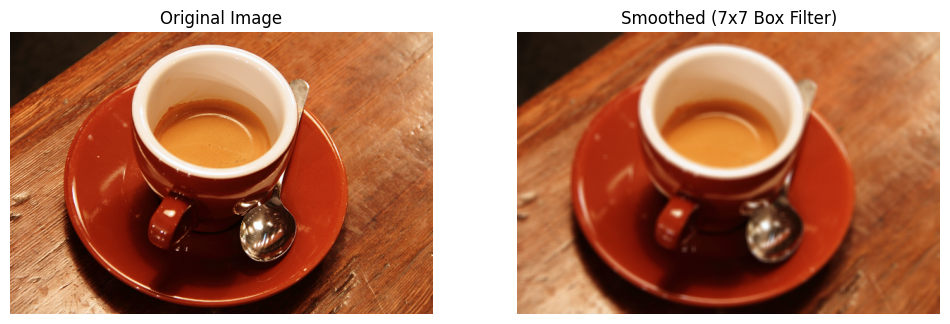

In [4]:
image = load_rgb('images/coffee.png')

# 7x7 box (averaging) kernel
kernel = np.ones((7, 7), np.float32) / (7 * 7)

# Convolve the image with the kernel
smoothed = cv2.filter2D(image, -1, kernel)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(image);    ax[0].set_title("Original Image");            ax[0].axis("off")
ax[1].imshow(smoothed); ax[1].set_title("Smoothed (7x7 Box Filter)"); ax[1].axis("off")
plt.show()

## Assessment – Task 2: 5x5 and 21x21 Gaussian Filters

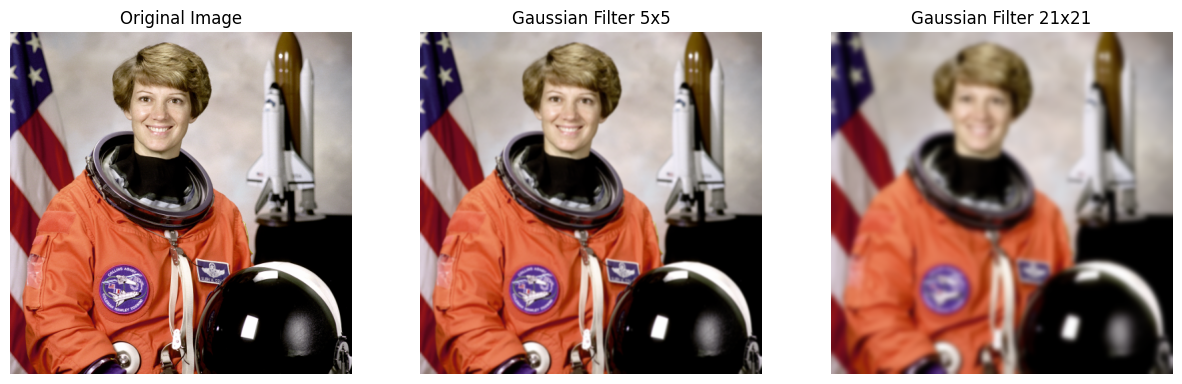

In [5]:
image = load_rgb('images/astronaut.png')

# Gaussian blur with sigma computed from the kernel size (sigma = 0)
gauss_5  = cv2.GaussianBlur(image, (5, 5), 0)
gauss_21 = cv2.GaussianBlur(image, (21, 21), 0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);    ax[0].set_title("Original Image");         ax[0].axis("off")
ax[1].imshow(gauss_5);  ax[1].set_title("Gaussian Filter 5x5");    ax[1].axis("off")
ax[2].imshow(gauss_21); ax[2].set_title("Gaussian Filter 21x21");  ax[2].axis("off")
plt.show()

## Assessment – Task 3: 3x3 Laplacian Sharpening

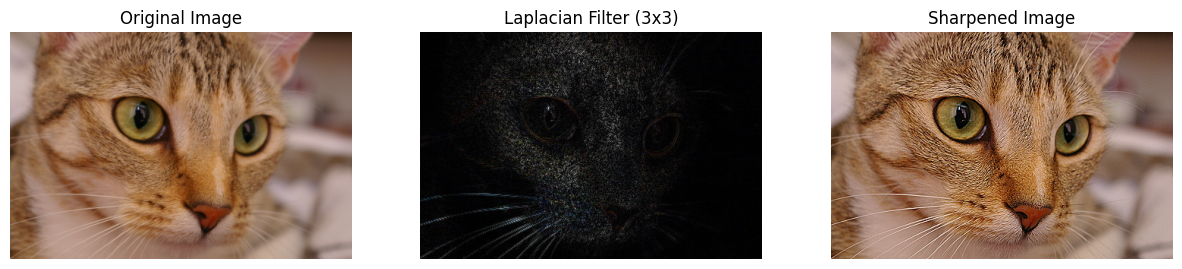

In [6]:
# Read the image
image = load_rgb('images/chelsea.png')

# Convert image to float32
image_float = image.astype(np.float32) / 255.0

# 3x3 Laplacian filter
laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=1)

# Sharpen the image
sharpened = np.clip(image_float - laplacian, 0, 1)

# Plot original, Laplacian, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image");  ax[0].axis("off")
ax[1].imshow(np.clip(np.abs(laplacian), 0, 1))
ax[1].set_title("Laplacian Filter (3x3)"); ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened Image"); ax[2].axis("off")
plt.show()